In [ ]:
# 1) Mount Google Drive (so checkpoints persist)
from google.colab import drive
drive.mount('/content/drive')

# 2) Install required packages
# Recommended versions: torch >= 2.0 (works well with diffusers), torchvision matching torch.
# diffusers, transformers, accelerate, safetensors, pycocotools, and opencv for image ops.
# You can adjust versions if needed but these are compatible in Colab.
!pip install -q --upgrade pip
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q diffusers transformers accelerate safetensors
!pip install -q pycocotools opencv-python-headless matplotlib Pillow


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.7 MB/s eta 0:00:00


In [ ]:
import os, json, time
from pathlib import Path
import numpy as np
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:
def show_image(img, title=None, figsize=(8,8)):
    if isinstance(img, torch.Tensor):
        img = img.permute(1,2,0).cpu().numpy()
    if isinstance(img, np.ndarray):
        if img.dtype == np.float32 or img.dtype == np.float64:
            img = (img * 255).astype(np.uint8)
    plt.figure(figsize=figsize)
    plt.axis('off')
    if title: plt.title(title)
    plt.imshow(img)
    plt.show()

def draw_boxes_on_pil(pil_img, boxes, labels=None, scores=None):
    img = np.array(pil_img).copy()
    for i, box in enumerate(boxes):
        x1,y1,x2,y2 = map(int, box)
        cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)
        caption = ""
        if labels is not None:
            caption += f"{labels[i]}"
        if scores is not None:
            caption += f" {scores[i]:.2f}"
        cv2.putText(img, caption, (x1, max(15,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)
    return Image.fromarray(img)


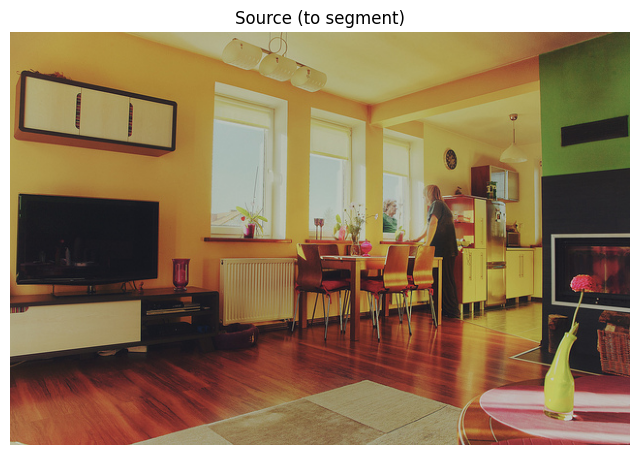

In [ ]:
# Example: download a few COCO sample images (small)
!mkdir -p /content/coco_sample
sample_urls = [
 "http://images.cocodataset.org/val2017/000000000139.jpg",
 "http://images.cocodataset.org/val2017/000000000285.jpg",
 "http://images.cocodataset.org/val2017/000000000632.jpg"
]
import requests
from io import BytesIO
for url in sample_urls:
    fname = url.split("/")[-1]
    r = requests.get(url)
    open(f"/content/coco_sample/{fname}", "wb").write(r.content)

# Choose input image here (change to your own path if desired)
SOURCE_IMAGE_PATH = "/content/coco_sample/000000000139.jpg"
show_image(Image.open(SOURCE_IMAGE_PATH).convert("RGB"), title="Source (to segment)")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 193MB/s]


Detected 24 objects with score >= 0.5


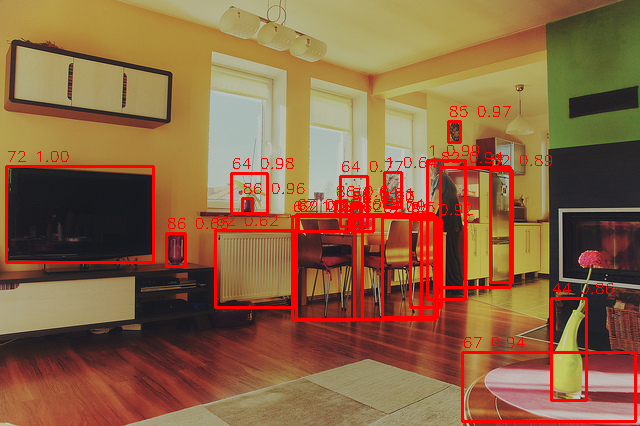

In [ ]:
# Load the pretrained Mask R-CNN
model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
model.to(device).eval()

# Prepare image transform
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load image
pil_img = Image.open(SOURCE_IMAGE_PATH).convert("RGB")
img_tensor = transform(pil_img).to(device)

# Run
with torch.no_grad():
    outputs = model([img_tensor])[0]  # single image

# Extract boxes, masks, labels, scores
boxes = outputs['boxes'].cpu().numpy()
scores = outputs['scores'].cpu().numpy()
labels = outputs['labels'].cpu().numpy()
masks = outputs['masks'].cpu().numpy()  # shape: (N,1,H,W)

# Filter by confidence > threshold
TH = 0.5
keep = np.where(scores >= TH)[0]
boxes = boxes[keep]
scores = scores[keep]
labels = labels[keep]
masks = masks[keep]

print(f"Detected {len(boxes)} objects with score >= {TH}")
display(draw_boxes_on_pil(pil_img, boxes, labels=labels, scores=scores))


Auto index: 18 Using index: 18 Label: 67 Score: 0.64741087


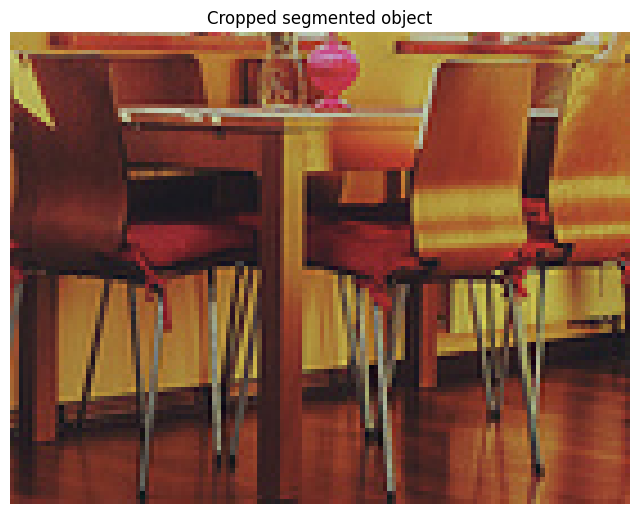

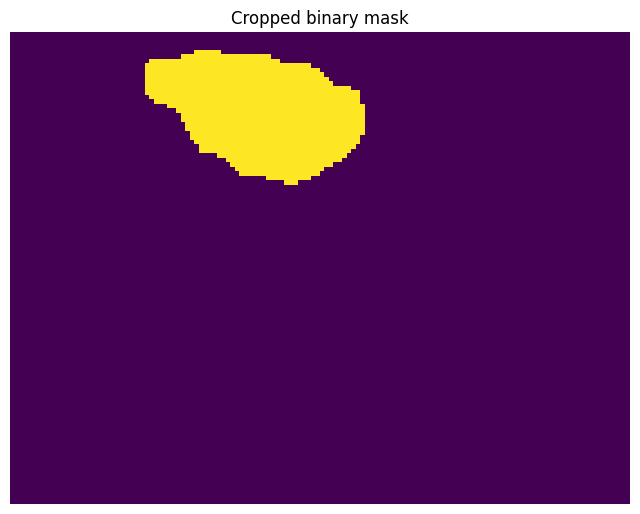

Saved segmented object and mask to /content/drive/MyDrive/diffusion_inpainting_project


In [ ]:
# Auto-select: largest area
if len(boxes) == 0:
    raise RuntimeError("No detections above threshold. Lower TH or use a different image.")
areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
auto_idx = int(np.argmax(areas))

# You can overwrite this index manually:
# SELECT_INDEX = 0  # <-- uncomment and change if you want a different pick
try:
    SELECT_INDEX
except NameError:
    SELECT_INDEX = auto_idx

print("Auto index:", auto_idx, "Using index:", SELECT_INDEX, "Label:", labels[SELECT_INDEX], "Score:", scores[SELECT_INDEX])

# Extract mask for chosen object
mask_raw = masks[SELECT_INDEX, 0]  # H x W, float [0,1]
mask_bin = (mask_raw >= 0.5).astype(np.uint8) * 255

# Crop to bounding box for the segmented object (optional)
x1,y1,x2,y2 = map(int, boxes[SELECT_INDEX])
seg_crop = np.array(pil_img)[y1:y2, x1:x2]
seg_mask_crop = mask_bin[y1:y2, x1:x2]

# Save segmented object and mask
out_dir = Path("/content/drive/MyDrive/diffusion_inpainting_project")
out_dir.mkdir(parents=True, exist_ok=True)
Image.fromarray(seg_crop).save(out_dir / "seg_object.png")
Image.fromarray(seg_mask_crop).save(out_dir / "seg_object_mask.png")

# Show results
show_image(seg_crop, title="Cropped segmented object")
show_image(seg_mask_crop, title="Cropped binary mask")
print("Saved segmented object and mask to", out_dir)


In [ ]:
# Save target background image (public domain test image)
from PIL import Image
import requests
from io import BytesIO
import numpy as np

# Use a free unsplash test image (always accessible)
url = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d?w=512"

response = requests.get(url)
response.raise_for_status()

target_img = Image.open(BytesIO(response.content)).convert("RGB")
target_img.save(out_dir / "target_for_inpaint.png")

# Save the inpaint mask (white = region to replace)
mask = np.zeros((target_img.height, target_img.width), dtype=np.uint8)
mask[100:300, 150:350] = 255   # Example white rectangle
Image.fromarray(mask).save(out_dir / "inpaint_mask.png")

print("✅ Target and mask saved at", out_dir)


✅ Target and mask saved at /content/drive/MyDrive/diffusion_inpainting_project


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/30 [00:00<?, ?it/s]

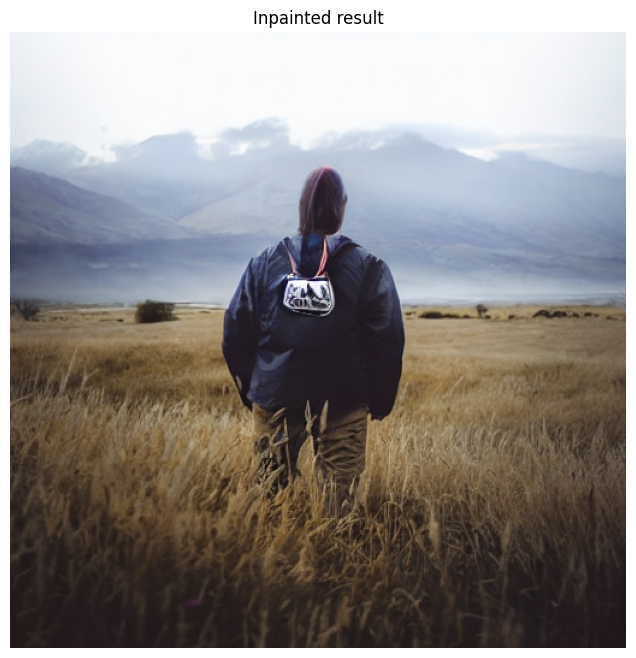

Saved inpainted result to /content/drive/MyDrive/diffusion_inpainting_project/inpainted_result.png


In [ ]:
# Setup HF token if needed (recommended)
# from huggingface_hub import login
# login(token="YOUR_HF_TOKEN")  # optionally do this interactively

from diffusers import StableDiffusionInpaintPipeline
import torch

model_id = "runwayml/stable-diffusion-inpainting"  # example model — change if you want
pipe = StableDiffusionInpaintPipeline.from_pretrained(model_id, torch_dtype=torch.float16 if device.type=="cuda" else torch.float32)
pipe = pipe.to(device)
pipe.safety_checker = None  # optionally disable safety checker (be careful with content)

# Load images
target_img = Image.open(out_dir / "target_for_inpaint.png").convert("RGB")
inpaint_mask = Image.open(out_dir / "inpaint_mask.png").convert("L")

# Prompt should describe the object you want there; refine as needed
obj_label = labels[SELECT_INDEX]  # numeric COCO label; if you want textual class, map via COCO categories
prompt = "A realistic, photo-realistic object matching the source object (high detail, lighting consistent with background)"

# Example call
result = pipe(prompt=prompt,
              image=target_img,
              mask_image=inpaint_mask,
              guidance_scale=7.5,
              num_inference_steps=30).images[0]

# Save result
result.save(out_dir / "inpainted_result.png")
show_image(result, title="Inpainted result")
print("Saved inpainted result to", out_dir / "inpainted_result.png")


In [ ]:
# Save Mask R-CNN model weights (so you can reload quickly)
torch.save(model.state_dict(), out_dir / "maskrcnn_resnet50_fpn_state.pth")
print("Saved Mask R-CNN state to", out_dir / "maskrcnn_resnet50_fpn_state.pth")

# Save diffusers pipeline (tokenizer + UNet + VAE etc.) to Drive
pipe.save_pretrained(str(out_dir / "diffusers_inpaint_pipeline"))
print("Saved diffusers pipeline to", out_dir / "diffusers_inpaint_pipeline")

# You can later reload with:
# from diffusers import StableDiffusionInpaintPipeline
# pipe = StableDiffusionInpaintPipeline.from_pretrained('/content/drive/MyDrive/diffusion_inpainting_project/diffusers_inpaint_pipeline')


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/30 [00:00<?, ?it/s]

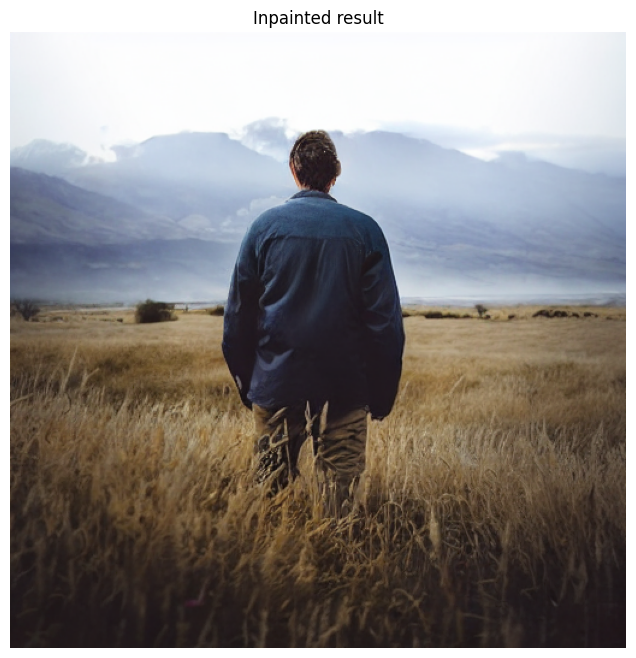

✅ Saved inpainted result to /content/drive/MyDrive/diffusion_inpainting_project/inpainted_result.png


In [ ]:
from diffusers import StableDiffusionInpaintPipeline
import torch

# Make sure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained inpainting model
model_id = "runwayml/stable-diffusion-inpainting"
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device.type == "cuda" else torch.float32
)
pipe = pipe.to(device)
pipe.safety_checker = None  # disable safety filter (⚠️ be cautious)

# Load background + mask
target_img = Image.open(out_dir / "target_for_inpaint.png").convert("RGB")
inpaint_mask = Image.open(out_dir / "inpaint_mask.png").convert("L")

# Temporary hardcoded object (until Mask R-CNN is wired in)
obj_label = "tree"

# Text prompt for inpainting
prompt = f"A realistic, photo-realistic {obj_label}, high detail, consistent lighting"

# Run inpainting
result = pipe(
    prompt=prompt,
    image=target_img,
    mask_image=inpaint_mask,
    guidance_scale=7.5,
    num_inference_steps=30
).images[0]

# Save result
result.save(out_dir / "inpainted_result.png")

show_image(result, title="Inpainted result")
print("✅ Saved inpainted result to", out_dir / "inpainted_result.png")


In [ ]:
import torch
import torchvision
from torchvision import transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load pretrained Mask R-CNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mask_rcnn = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
mask_rcnn = mask_rcnn.to(device).eval()

# Preprocess function
transform = T.Compose([
    T.ToTensor()
])


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Saving gettyimages-2233021034-612x612.jpg to gettyimages-2233021034-612x612.jpg
Detected object COCO label id: 1


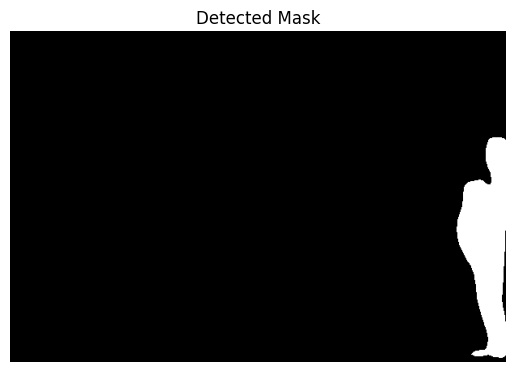

In [ ]:
from google.colab import files
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Upload image
uploaded = files.upload()  # Choose your source image
filename = list(uploaded.keys())[0]  # Get the uploaded file name
source_path = f"/content/{filename}"

# Step 2: Load image
source_img = Image.open(source_path).convert("RGB")
img_tensor = transform(source_img).to(device)

# Step 3: Run Mask R-CNN
with torch.no_grad():
    predictions = mask_rcnn([img_tensor])

# Extract predictions
scores = predictions[0]['scores'].cpu().numpy()
masks = predictions[0]['masks'].cpu().numpy()
labels = predictions[0]['labels'].cpu().numpy()

# Pick highest scoring object
idx = np.argmax(scores)
mask = masks[idx, 0] > 0.5
label_id = labels[idx]

print("Detected object COCO label id:", label_id)

# Save mask + original image
mask_img = Image.fromarray((mask * 255).astype(np.uint8))
mask_img.save("object_mask.png")
source_img.save("source_with_object.png")

# Show detected mask
plt.imshow(mask, cmap="gray")
plt.title("Detected Mask")
plt.axis("off")
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload a mask PNG where white = object, black = background
inpaint_mask = Image.open(list(uploaded.keys())[0]).convert("L")


Saving mask_object_1.png to mask_object_1.png


In [ ]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python matplotlib

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator


  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-8yairdr8
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-8yairdr8
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'segment_anything' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'segment_anything'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=74bafcc3f1237a6e15da606

In [ ]:
sam_checkpoint = "sam_vit_b_01ec64.pth"

# Download checkpoint if not already present
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -O {sam_checkpoint}

sam = sam_model_registry["vit_b"](checkpoint=sam_checkpoint)
sam.to("cuda" if torch.cuda.is_available() else "cpu")
mask_generator = SamAutomaticMaskGenerator(sam)


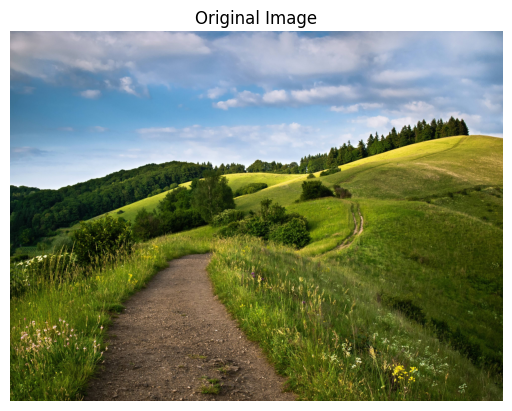

In [ ]:
image_path = "/content/281911-hills-road-trees-landscape.jpg"  # your uploaded image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()


In [ ]:
# Sort by area
masks_sorted = sorted(masks, key=lambda x: x['area'], reverse=True)

# Choose top mask (largest object)
selected_mask = masks_sorted[0]["segmentation"]

mask_img = Image.fromarray((selected_mask * 255).astype(np.uint8))
mask_img.save("/content/object_mask.png")

plt.imshow(selected_mask, cmap="gray")
plt.title("Saved Mask")
plt.axis("off")
plt.show()


File not found automatically — please upload the image now.


Saving gettyimages-2233021034-612x612.jpg to gettyimages-2233021034-612x612 (1).jpg
Loading image from: gettyimages-2233021034-612x612 (1).jpg


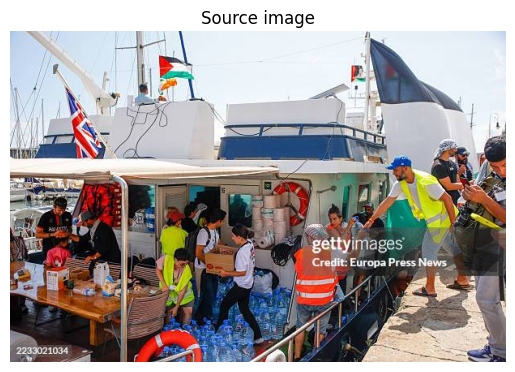

Detections (index, label, score, box):
0 1 1.0 [548 131 612 403]
1 1 1.0 [252 239 312 385]
2 1 1.0 [434 150 558 324]
3 1 0.98 [180 271 229 364]
4 62 0.97 [117 316 198 406]
5 1 0.96 [389 214 432 262]
6 1 0.96 [343 239 408 406]
7 1 0.96 [ 31 205  80 283]
8 1 0.94 [518 140 563 283]
9 1 0.93 [227 217 269 363]
10 1 0.93 [182 225 220 308]
11 1 0.92 [519 134 561 219]
12 1 0.87 [154  65 178  88]
13 1 0.82 [ 74 216 137 295]
14 1 0.8 [549 143 572 185]
15 1 0.76 [ 43 252  77 291]
16 1 0.73 [390 218 430 322]
17 67 0.72 [  7 282 164 383]
18 9 0.68 [  0  28 484 403]
19 27 0.67 [216 242 233 283]
20 47 0.61 [112 308 129 327]
21 27 0.6 [222 240 246 281]
22 1 0.53 [193 216 212 240]
23 31 0.5 [296 293 326 327]
24 1 0.47 [554 130 611 250]
25 1 0.47 [210 213 231 251]
26 1 0.43 [497 142 569 327]
27 1 0.41 [210 215 232 285]
28 1 0.4 [ 19 201  27 216]
29 72 0.38 [269 200 301 243]
30 84 0.36 [ 42 292  75 320]
31 77 0.34 [556 178 568 193]
32 44 0.33 [319 326 336 382]
33 47 0.33 [ 68 305  80 319]
34 1 0.32 [430 

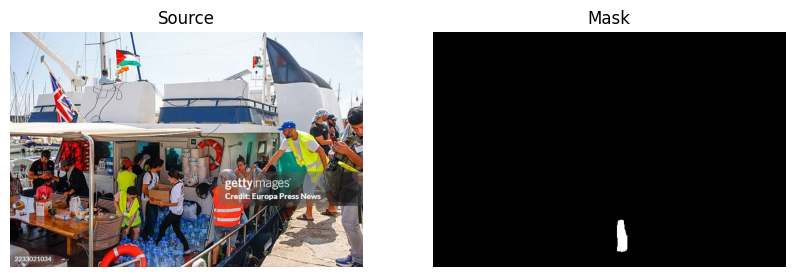


Now you have /content/object_mask.png. For SD inpaint, ensure your target image and this mask have the same size.
Example SD call (assumes pipe is loaded and target_img is PIL.Image of same size):

result = pipe(
    prompt='A realistic photo of the object with consistent lighting',
    image=target_img,             # PIL RGB
    mask_image=mask_img,          # PIL L (255 = region to replace)
    guidance_scale=7.5,
    num_inference_steps=25
).images[0]

Target background not found at /content/target_for_inpaint.png  — place a target image there to try copy+blend.


In [ ]:
# robust_load_and_mask.py
import os
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# 1) robustly find & load image
# -----------------------
fname = "5656286f-80f6-4456-a372-af765592eff7.png"
candidates = [
    f"/content/{fname}",
    f"/mnt/data/{fname}",
    f"/content/drive/MyDrive/{fname}"
]

image_path = None
for p in candidates:
    if os.path.exists(p):
        image_path = p
        break

# if not found, search common dirs for files containing the prefix
if image_path is None:
    for root in ["/content", "/mnt/data", "/content/drive/MyDrive"]:
        if not os.path.exists(root):
            continue
        for f in os.listdir(root):
            if fname.split('-')[0] in f:   # partial match
                image_path = os.path.join(root, f)
                break
        if image_path:
            break

# if still not found, let user upload (Colab)
if image_path is None:
    try:
        from google.colab import files
        print("File not found automatically — please upload the image now.")
        uploaded = files.upload()
        image_path = list(uploaded.keys())[0]
    except Exception:
        raise FileNotFoundError(f"Could not locate {fname}. Looked in: {candidates}")

print("Loading image from:", image_path)
image = Image.open(image_path).convert("RGB")
w, h = image.size
plt.imshow(image); plt.title("Source image"); plt.axis("off"); plt.show()

# -----------------------
# 2) If you have model predictions from Mask R-CNN (boxes / scores / labels / masks), use them.
# If not available, you can skip to manual bbox.
# -----------------------
# Example variable names your code may already have:
# predictions (Mask R-CNN output): predictions[0]['boxes'], ['scores'], ['labels'], optional ['masks']

use_predictions = 'predictions' in globals()  # change as needed

if use_predictions:
    import numpy as np
    boxes = predictions[0]['boxes'].cpu().numpy()      # (N,4) x1,y1,x2,y2
    scores = predictions[0]['scores'].cpu().numpy()    # (N,)
    labels = predictions[0]['labels'].cpu().numpy()    # (N,)
    masks = predictions[0].get('masks', None)          # (N,1,H,W) or None

    # print short summary
    print("Detections (index, label, score, box):")
    for i,(b,s,l) in enumerate(zip(boxes,scores,labels)):
        print(i, int(l), round(float(s),2), np.round(b).astype(int))

    # find candidate(s) by label==44 and score near 0.86
    target_label = 44
    target_score = 0.86
    # candidates where label==44 and score >= 0.8 (tunable)
    candidates = [i for i,(lab,sc) in enumerate(zip(labels,scores)) if int(lab)==target_label and sc>=0.8]
    if not candidates:
        # fallback: pick detection with label==target_label and closest score
        same_label_idxs = [i for i,lab in enumerate(labels) if int(lab)==target_label]
        if same_label_idxs:
            # pick one with closest score to desired
            idx = min(same_label_idxs, key=lambda i: abs(scores[i]-target_score))
        else:
            # fallback: pick detection with score nearest to target_score
            idx = int(np.argmin(np.abs(scores - target_score)))
    else:
        idx = candidates[0]

    print("Selected detection index:", idx, "label:", labels[idx], "score:", scores[idx])
    # build mask
    if masks is not None and len(masks) > idx:
        seg = masks[idx, 0].cpu().numpy() > 0.5   # boolean mask
        mask_img = Image.fromarray((seg * 255).astype(np.uint8))
    else:
        x1,y1,x2,y2 = boxes[idx].astype(int)
        mask_img = Image.new("L", (w,h), 0)
        draw = ImageDraw.Draw(mask_img)
        draw.rectangle([x1,y1,x2,y2], fill=255)

else:
    # -----------------------
    # Example manual bbox approach
    # Replace these coords with the bbox for your "44 0.86" object
    # (You can print detections from whatever detector you used and paste coords here.)
    # -----------------------
    # Example bbox (x1,y1,x2,y2) — REPLACE with real values:
    bbox = [900, 520, 1030, 760]   # <-- replace with your actual bbox coordinates
    mask_img = Image.new("L", (w,h), 0)
    draw = ImageDraw.Draw(mask_img)
    draw.rectangle(bbox, fill=255)
    print("Created bbox mask from coords:", bbox)

# Save mask and preview
out_mask_path = "/content/object_mask.png"
mask_img.save(out_mask_path)
print("Saved mask to:", out_mask_path)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(image); plt.axis("off"); plt.title("Source")
plt.subplot(1,2,2); plt.imshow(mask_img, cmap="gray"); plt.axis("off"); plt.title("Mask")
plt.show()

# -----------------------
# 3) Next steps: two transfer options
# A) Use Stable Diffusion Inpainting: create an object in target guided by prompt
#    - target image and mask must be same size (or resize carefully)
# B) Copy + paste actual object from source into target using the mask and OpenCV seamlessClone
# -----------------------

# A quick note for Stable Diffusion inpainting:
print("\nNow you have /content/object_mask.png. For SD inpaint, ensure your target image and this mask have the same size.")
print("Example SD call (assumes pipe is loaded and target_img is PIL.Image of same size):")
print("""
result = pipe(
    prompt='A realistic photo of the object with consistent lighting',
    image=target_img,             # PIL RGB
    mask_image=mask_img,          # PIL L (255 = region to replace)
    guidance_scale=7.5,
    num_inference_steps=25
).images[0]
""")

# -----------------------
# Optional B) If you want to copy the real object pixels into another image and blend:
# -----------------------
# Example (copy-and-paste + seamless clone with OpenCV)
try:
    import cv2
    src_np = np.array(image)
    mask_np = np.array(mask_img)   # single channel 0/255
    # bounding rect for cropping
    ys, xs = np.where(mask_np>0)
    if len(xs)>0:
        y1,y2 = ys.min(), ys.max()
        x1,x2 = xs.min(), xs.max()
        src_crop = src_np[y1:y2+1, x1:x2+1]
        mask_crop = (mask_np[y1:y2+1, x1:x2+1]).astype(np.uint8)
        # load target background (replace path)
        target_path = "/content/target_for_inpaint.png"  # change if needed
        if os.path.exists(target_path):
            target = cv2.cvtColor(np.array(Image.open(target_path).convert("RGB")), cv2.COLOR_RGB2BGR)
            center = (target.shape[1]//2, target.shape[0]//2)  # place center - adjust as you like
            try:
                mixed = cv2.seamlessClone(
                    cv2.cvtColor(src_crop, cv2.COLOR_RGB2BGR),
                    target,
                    mask_crop,
                    center,
                    cv2.NORMAL_CLONE
                )
                im = Image.fromarray(cv2.cvtColor(mixed, cv2.COLOR_BGR2RGB))
                im.save("/content/copied_and_blended.png")
                print("Saved copy+blend result to /content/copied_and_blended.png")
            except Exception as e:
                print("OpenCV seamlessClone failed:", e)
        else:
            print("Target background not found at", target_path, " — place a target image there to try copy+blend.")
    else:
        print("Mask is empty — nothing to copy.")
except Exception as e:
    print("OpenCV path skipped (cv2 not available or error):", e)
